In [1]:
import pandas as pd

df = pd.read_csv('ESS11e04_1.csv', usecols=[
    'vote', 
    #socio-demo-econ
    'agea', 'cntry', 'gndr', 'eduyrs', 'hinctnta',
    #trust
    'trstprl', 'trstplt', 'trstprt', 'trstlgl',
    #politics
    'polintr', 'lrscale',
    'cptppola', 'psppsgva', 'psppipla',
    'contplt', 'sgnptit', 'clsprty',
    #satisfaction
    'stfdem', 'stfgov', 'stfeco', 
    #internet and news
    'nwspol', 'netusoft',
    #weights
    'pspwght', 'anweight'
])

In [2]:
# MAP WITH SURVEY PARTICIPATION
import plotly.express as px

# Compute each country's share of the total ESS11 sample (%)
total_respondents = len(df)
# Create a new dataframe "participation_rate" used just for the map
participation_rate = df['cntry'].value_counts().reset_index()
participation_rate.columns = ['cntry_iso2', 'n_respondents']
participation_rate['sample_share_pct'] = (participation_rate['n_respondents'] / total_respondents * 100).round(2)

# Change country codes to 3-letter ISO codes for plotly map libary
iso2_to_iso3 = {
    'AT': 'AUT', 'BE': 'BEL', 'BG': 'BGR', 'CH': 'CHE', 'CY': 'CYP',
    'CZ': 'CZE', 'DE': 'DEU', 'DK': 'DNK', 'EE': 'EST', 'ES': 'ESP',
    'FI': 'FIN', 'FR': 'FRA', 'GB': 'GBR', 'GR': 'GRC', 'HR': 'HRV',
    'HU': 'HUN', 'IE': 'IRL', 'IS': 'ISL', 'IT': 'ITA', 'LT': 'LTU',
    'LV': 'LVA', 'ME': 'MNE', 'MK': 'MKD', 'NL': 'NLD', 'NO': 'NOR',
    'PL': 'POL', 'PT': 'PRT', 'RO': 'ROU', 'RS': 'SRB', 'SE': 'SWE',
    'SI': 'SVN', 'SK': 'SVK',
}
participation_rate['iso3'] = participation_rate['cntry_iso2'].map(iso2_to_iso3)

fig2 = px.choropleth(
    participation_rate,
    locations='iso3',
    color='sample_share_pct',
    hover_name='cntry_iso2',
    hover_data={'sample_share_pct': ':.2f', 'n_respondents': True, 'iso3': False},
    color_continuous_scale='Blues',
    scope='europe',
    title=f'ESS Round 11 — Rate of survey participation per country (%) (N={total_respondents:,})',
    labels={'sample_share_pct': '% of sample'},
)
fig2.update_layout(
    geo=dict(showframe=False, showcoastlines=True),
    margin=dict(l=0, r=0, t=40, b=0),
)
fig2.show()

print(participation_rate[['cntry_iso2', 'n_respondents', 'sample_share_pct']]
      .sort_values('sample_share_pct', ascending=False)
      .to_string(index=False))


cntry_iso2  n_respondents  sample_share_pct
        IT           2865              5.72
        GR           2757              5.50
        UA           2661              5.31
        DE           2420              4.83
        AT           2354              4.70
        BG           2239              4.47
        HU           2118              4.23
        IE           2017              4.02
        ES           1844              3.68
        FR           1771              3.53
        NL           1695              3.38
        GB           1684              3.36
        ME           1609              3.21
        BE           1594              3.18
        HR           1563              3.12
        RS           1563              3.12
        FI           1563              3.12
        PL           1442              2.88
        SK           1442              2.88
        CH           1384              2.76
        PT           1373              2.74
        LT           1365       

In [ ]:
df.describe()

── Raw distribution of 'vote' ──────────────────────────
                  Count  % of total
vote                               
1 – Yes           36293       72.42
2 – No            10177       20.31
3 – Not eligible   3151        6.29
7 – Refusal         227        0.45
8 – Don't know      246        0.49
9 – No answer        22        0.04

True NaN (empty cells): 0
Total rows: 50,116


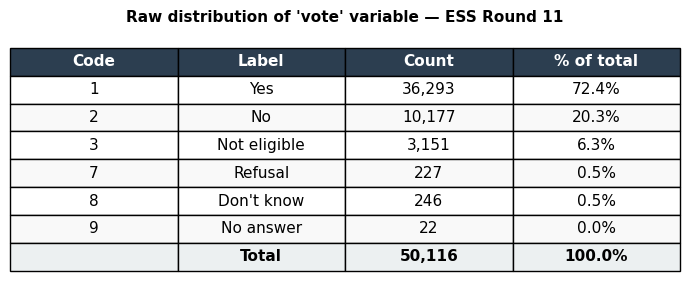

In [3]:
# ── DEPENDENT VARIABLE: vote ──────────────────────────────────────────────────
# ESS question: "Did you vote in the last [country] national election?"
#
# Coded values:
#   1 = Yes
#   2 = No
#   3 = Not eligible to vote
#   7 = Refusal
#   8 = Don't know
#   9 = No answer

import matplotlib.pyplot as plt
import numpy as np

vote_labels = {1: 'Yes', 2: 'No', 3: 'Not eligible', 7: 'Refusal', 8: "Don't know", 9: 'No answer'}

raw_counts = df['vote'].value_counts().sort_index()
raw_pct    = df['vote'].value_counts(normalize=True).sort_index() * 100

overview = (
    raw_counts.rename('Count')
    .to_frame()
    .join(raw_pct.rename('% of total').round(2))
)
overview.index = overview.index.map(lambda x: f"{int(x)} – {vote_labels.get(int(x), '?')}")

print("── Raw distribution of 'vote' ──────────────────────────")
print(overview.to_string())
print(f"\nTrue NaN (empty cells): {df['vote'].isna().sum()}")
print(f"Total rows: {len(df):,}")

# ── Table figure (export-ready for Word) ──────────────────────────────────────
table_data = [
    [code, vote_labels[code], f"{raw_counts[code]:,}", f"{raw_pct[code]:.1f}%"]
    for code in raw_counts.index
]
table_data.append(['', 'Total', f"{raw_counts.sum():,}", '100.0%'])

col_labels = ['Code', 'Label', 'Count', '% of total']

fig, ax = plt.subplots(figsize=(7, 3))
ax.axis('off')
tbl = ax.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.6)

# Style header row
for col in range(len(col_labels)):
    tbl[0, col].set_facecolor('#2c3e50')
    tbl[0, col].set_text_props(color='white', fontweight='bold')

# Style total row
total_row = len(table_data)
for col in range(len(col_labels)):
    tbl[total_row, col].set_facecolor('#ecf0f1')
    tbl[total_row, col].set_text_props(fontweight='bold')

# Alternating row colours
for row in range(1, len(table_data)):
    colour = '#f9f9f9' if row % 2 == 0 else 'white'
    for col in range(len(col_labels)):
        if row < total_row:
            tbl[row, col].set_facecolor(colour)

plt.title("Raw distribution of 'vote' variable — ESS Round 11",
          fontsize=11, pad=12, fontweight='bold')
plt.tight_layout()
plt.savefig('table_vote_raw.png', dpi=200, bbox_inches='tight')
plt.show()


In [4]:
# ── STEP 1: Exclude respondents not eligible to vote (code 3) ─────────────────
# These are a different population (non-citizens, too young, etc.)
# and cannot be treated as non-voters — they must be dropped entirely.

n_before = len(df)
df = df[df['vote'] != 3]
n_dropped_ineligible = n_before - len(df)
print(f"Dropped 'not eligible' (code 3): {n_dropped_ineligible:,} rows")

# ── STEP 2: Exclude non-response codes (7 = Refusal, 8 = Don't know, 9 = No answer)
# These are uninformative — we cannot assign them to voted/not voted.
n_before = len(df)
df = df[df['vote'].isin([1, 2])]
n_dropped_nonresponse = n_before - len(df)
print(f"Dropped non-response (codes 7/8/9): {n_dropped_nonresponse:,} rows")

print(f"\nRemaining rows: {len(df):,}")
print(df['vote'].value_counts().rename(index={1: 'Yes (1)', 2: 'No (2)'}).to_string())


Dropped 'not eligible' (code 3): 3,151 rows
Dropped non-response (codes 7/8/9): 495 rows

Remaining rows: 46,470
vote
Yes (1)    36293
No (2)     10177


── Final distribution of 'vote' (dependent variable) ──
  0 – Did not vote: 10,177  (21.9%)
  1 – Voted: 36,293  (78.1%)

  Class imbalance ratio (voted/not voted): 3.57


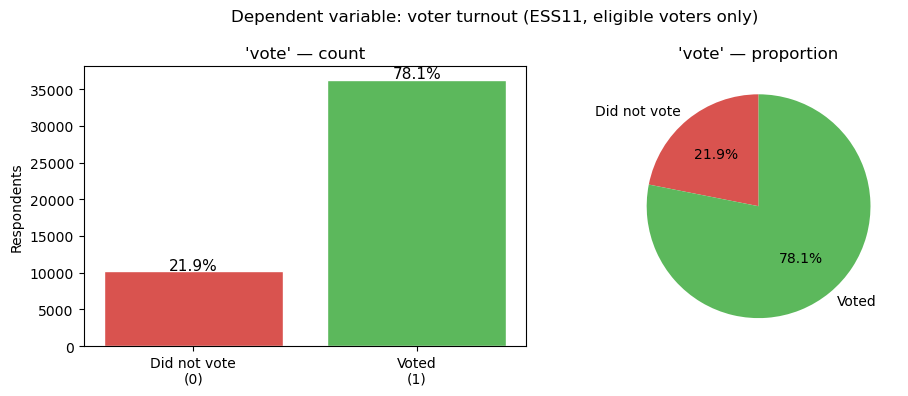

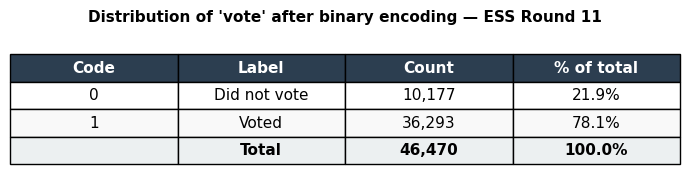

In [5]:
# ── STEP 3: Binary encoding ───────────────────────────────────────────────────
# Recode: 1 (Yes) → 1, 2 (No) → 0
# This creates the target variable 'voted' used in all models.

df['vote'] = (df['vote'] == 1).astype(int)

counts = df['vote'].value_counts().sort_index()
pcts   = df['vote'].value_counts(normalize=True).sort_index() * 100

print("── Final distribution of 'vote' (dependent variable) ──")
for val, label in zip([0, 1], ['0 – Did not vote', '1 – Voted']):
    print(f"  {label}: {counts[val]:,}  ({pcts[val]:.1f}%)")
print(f"\n  Class imbalance ratio (voted/not voted): {counts[1]/counts[0]:.2f}")

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Did not vote\n(0)', 'Voted\n(1)'], counts.values, color=['#d9534f', '#5cb85c'], edgecolor='white')
axes[0].set_title("'vote' — count")
axes[0].set_ylabel('Respondents')
for i, (c, p) in enumerate(zip(counts.values, pcts.values)):
    axes[0].text(i, c + 200, f'{p:.1f}%', ha='center', fontsize=11)

axes[1].pie(counts.values, labels=['Did not vote', 'Voted'], autopct='%1.1f%%',
            colors=['#d9534f', '#5cb85c'], startangle=90)
axes[1].set_title("'vote' — proportion")

plt.suptitle("Dependent variable: voter turnout (ESS11, eligible voters only)", fontsize=12)
plt.tight_layout()
plt.show()

# ── Table figure (export-ready for Word) ──────────────────────────────────────
table_data = [
    ['0', 'Did not vote', f"{counts[0]:,}", f"{pcts[0]:.1f}%"],
    ['1', 'Voted',        f"{counts[1]:,}", f"{pcts[1]:.1f}%"],
    ['',  'Total',        f"{counts.sum():,}", '100.0%'],
]
col_labels = ['Code', 'Label', 'Count', '% of total']

fig2, ax2 = plt.subplots(figsize=(7, 2))
ax2.axis('off')
tbl = ax2.table(
    cellText=table_data,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.8)

# Header
for col in range(len(col_labels)):
    tbl[0, col].set_facecolor('#2c3e50')
    tbl[0, col].set_text_props(color='white', fontweight='bold')

# Data rows
row_colours = ['white', '#f9f9f9']
for row in range(1, 3):
    for col in range(len(col_labels)):
        tbl[row, col].set_facecolor(row_colours[row - 1])

# Total row
for col in range(len(col_labels)):
    tbl[3, col].set_facecolor('#ecf0f1')
    tbl[3, col].set_text_props(fontweight='bold')

plt.title("Distribution of 'vote' after binary encoding — ESS Round 11",
          fontsize=11, pad=12, fontweight='bold')
plt.tight_layout()
plt.savefig('table_vote_binary.png', dpi=200, bbox_inches='tight')
plt.show()
